# PCA Implementations

## 1) Loading the High Dimension Dataset

In [69]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

print(f"1) Original shape: {X.shape}\n")
print(f"2) Features: {data.feature_names}\n")
print(f"3) Target classes: {data.target_names}\n")

1) Original shape: (569, 30)

2) Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

3) Target classes: ['malignant' 'benign']



## 2) Visualize the high dimentions data

In [70]:
# Step 1: Standardize the data (important before PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Apply PCA - reduce 30 features to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Reduced shape: {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

Reduced shape: (569, 2)
Explained variance ratio: [0.44272026 0.18971182]
Total variance explained: 0.6324


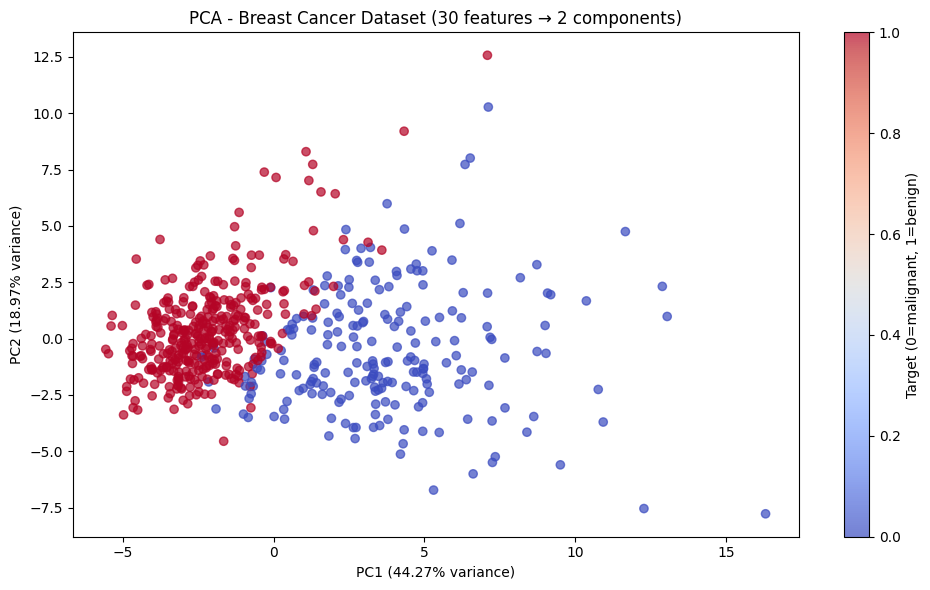

In [71]:
import matplotlib.pyplot as plt

# Visualize PCA result
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter, label='Target (0=malignant, 1=benign)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('PCA - Breast Cancer Dataset (30 features → 2 components)')
plt.tight_layout()
plt.show()

## 3) Check PCA and Without PCA Comparision

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Step 1: Train-test split (raw data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- KNN WITHOUT PCA (using all 30 features) ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
acc_before = accuracy_score(y_test, knn.predict(X_test_scaled))
print(f"KNN Accuracy WITHOUT PCA (30 features): {acc_before:.4f}")

# --- KNN WITH PCA (reduce to 2 components) ---
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)
acc_after = accuracy_score(y_test, knn_pca.predict(X_test_pca))
print(f"KNN Accuracy WITH PCA  (2 features):  {acc_after:.4f}")

print(f"\nDifference: {acc_before - acc_after:.4f}")

KNN Accuracy WITHOUT PCA (30 features): 0.9474
KNN Accuracy WITH PCA  (2 features):  0.9737

Difference: -0.0263


In [73]:
print("The two principal components are able to capture {:.2f}% variance out of 100% from the total data".format(sum(pca.explained_variance_ratio_)*100))

The two principal components are able to capture 63.00% variance out of 100% from the total data


## 4) How to Select the Best Component Value

In [74]:
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [75]:
pca.explained_variance_ratio_.shape[0] # this gives no of principle components (which is same as number of features)

30

In [76]:
pca.components_.shape # this gives the actual principal components (eigenvectors) (30 principle components in 30 dimentional space)

(30, 30)

In [77]:
pca.explained_variance_ratio_ # this gives the variance explained by each principal component (30 values for 30 components)
                              # fisrt component ley 0.43 variance capture garya xa  second component 0.19 variance capture garya xa, and so on...

array([4.35027816e-01, 1.95000069e-01, 9.78151887e-02, 6.48640944e-02,
       5.25337760e-02, 4.11279962e-02, 2.23559034e-02, 1.64795219e-02,
       1.38005190e-02, 1.20526216e-02, 1.05656532e-02, 8.83487978e-03,
       7.72384348e-03, 5.31689053e-03, 2.90035907e-03, 2.74863963e-03,
       2.02120554e-03, 1.81312048e-03, 1.63703163e-03, 1.03921453e-03,
       9.98523858e-04, 8.78835623e-04, 8.09819261e-04, 5.76666950e-04,
       4.96295906e-04, 2.76290404e-04, 2.25813282e-04, 5.07660981e-05,
       2.45885848e-05, 4.05623540e-06])

In [78]:
np.cumsum(pca.explained_variance_ratio_) # left to right sum step by step 

array([0.43502782, 0.63002788, 0.72784307, 0.79270717, 0.84524094,
       0.88636894, 0.90872484, 0.92520437, 0.93900488, 0.95105751,
       0.96162316, 0.97045804, 0.97818188, 0.98349877, 0.98639913,
       0.98914777, 0.99116898, 0.9929821 , 0.99461913, 0.99565834,
       0.99665687, 0.9975357 , 0.99834552, 0.99892219, 0.99941849,
       0.99969478, 0.99992059, 0.99997136, 0.99999594, 1.        ])

In [79]:
np.cumsum(pca.explained_variance_ratio_)*100 # percentage of variance explained by each component

array([ 43.50278158,  63.00278847,  72.78430734,  79.27071678,
        84.52409438,  88.636894  ,  90.87248434,  92.52043653,
        93.90048843,  95.10575059,  96.16231591,  97.04580389,
        97.81818824,  98.34987729,  98.6399132 ,  98.91477716,
        99.11689772,  99.29820976,  99.46191293,  99.56583438,
        99.66568677,  99.75357033,  99.83455225,  99.89221895,
        99.94184854,  99.96947758,  99.99205891,  99.99713552,
        99.99959438, 100.        ])

In [80]:
variance_captured = np.cumsum(pca.explained_variance_ratio_)*100
which_component = [f'PC{i+1}' for i in range(len(variance_captured))]
combined_variance_component = list(zip(which_component, variance_captured))
combined_variance_component[:4]

[('PC1', np.float64(43.502781583337615)),
 ('PC2', np.float64(63.00278846854035)),
 ('PC3', np.float64(72.78430734090061)),
 ('PC4', np.float64(79.27071678358473))]

In [81]:
df=pd.DataFrame(data=combined_variance_component, columns=['Principal Component', 'Variance Captured %'])
df

,Principal Component,Variance Captured %
0,PC1,43.502782
1,PC2,63.002788
2,PC3,72.784307
3,PC4,79.270717
4,PC5,84.524094
5,PC6,88.636894
6,PC7,90.872484
7,PC8,92.520437
8,PC9,93.900488
9,PC10,95.105751


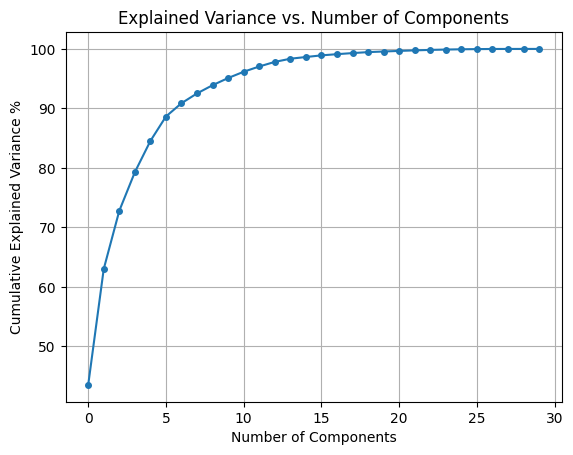

In [82]:
plt.plot(variance_captured, marker='o', markersize=4) 
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance %')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

In [83]:
# lets go with 20 components as it captures 99% variance of the data, and we can reduce our 30 features to 20 features without losing much information.

# --- KNN WITH PCA (reduce to 13 components as it captures 98% variance of the data) ---
pca = PCA(n_components=13)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn_pca = KNeighborsClassifier(n_neighbors=4)
knn_pca.fit(X_train_pca, y_train)
acc_after = accuracy_score(y_test, knn_pca.predict(X_test_pca))
print(f"KNN Accuracy WITH PCA  (13 features):  {acc_after:.4f}")

KNN Accuracy WITH PCA  (13 features):  0.9561
